In [18]:
!pip install textblob

# import all the required libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob

import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shourya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shourya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
df1 = pd.read_csv(r"C:\Users\Shourya\Documents\amazon project/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")
df2 = pd.read_csv(r"C:\Users\Shourya\Documents\amazon project/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")

In [20]:
df1.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-09-18T00:00:00Z,2017...",False,NaN,0,3,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-07-07T00:00:00Z,2017...",True,NaN,0,5,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,4,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...
3,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-10-09T00:00:00Z,True,177283626.0,3,5,https://redsky.target.com/groot-domain-api/v1/...,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,https://www.newegg.com/Product/Product.aspx%25...
4,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,5,https://reviews.bestbuy.com/3545/5442403/revie...,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,https://www.newegg.com/Product/Product.aspx%25...


In [21]:
df2.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [22]:
df1.shape
df1.columns
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5000 non-null   object 
 1   dateAdded            5000 non-null   object 
 2   dateUpdated          5000 non-null   object 
 3   name                 5000 non-null   object 
 4   asins                5000 non-null   object 
 5   brand                5000 non-null   object 
 6   categories           5000 non-null   object 
 7   primaryCategories    5000 non-null   object 
 8   imageURLs            5000 non-null   object 
 9   keys                 5000 non-null   object 
 10  manufacturer         5000 non-null   object 
 11  manufacturerNumber   5000 non-null   object 
 12  reviews.date         5000 non-null   object 
 13  reviews.dateAdded    1052 non-null   object 
 14  reviews.dateSeen     5000 non-null   object 
 15  reviews.doRecommend  5000 non-null   b

In [23]:
df2.shape
df2.columns
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  16086 non-null 

In [24]:
print(df1.isnull().sum())

id                        0
dateAdded                 0
dateUpdated               0
name                      0
asins                     0
brand                     0
categories                0
primaryCategories         0
imageURLs                 0
keys                      0
manufacturer              0
manufacturerNumber        0
reviews.date              0
reviews.dateAdded      3948
reviews.dateSeen          0
reviews.doRecommend       0
reviews.id             4971
reviews.numHelpful        0
reviews.rating            0
reviews.sourceURLs        0
reviews.text              0
reviews.title            13
reviews.username          1
sourceURLs                0
dtype: int64


In [25]:
print(df2.isnull().sum())

id                         0
dateAdded                  0
dateUpdated                0
name                       0
asins                      0
brand                      0
categories                 0
primaryCategories          0
imageURLs                  0
keys                       0
manufacturer               0
manufacturerNumber         0
reviews.date               0
reviews.dateSeen           0
reviews.didPurchase    28323
reviews.doRecommend    12246
reviews.id             28291
reviews.numHelpful     12217
reviews.rating             0
reviews.sourceURLs         0
reviews.text               0
reviews.title              0
reviews.username           5
sourceURLs                 0
dtype: int64


In [26]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [27]:
import missingno as msno

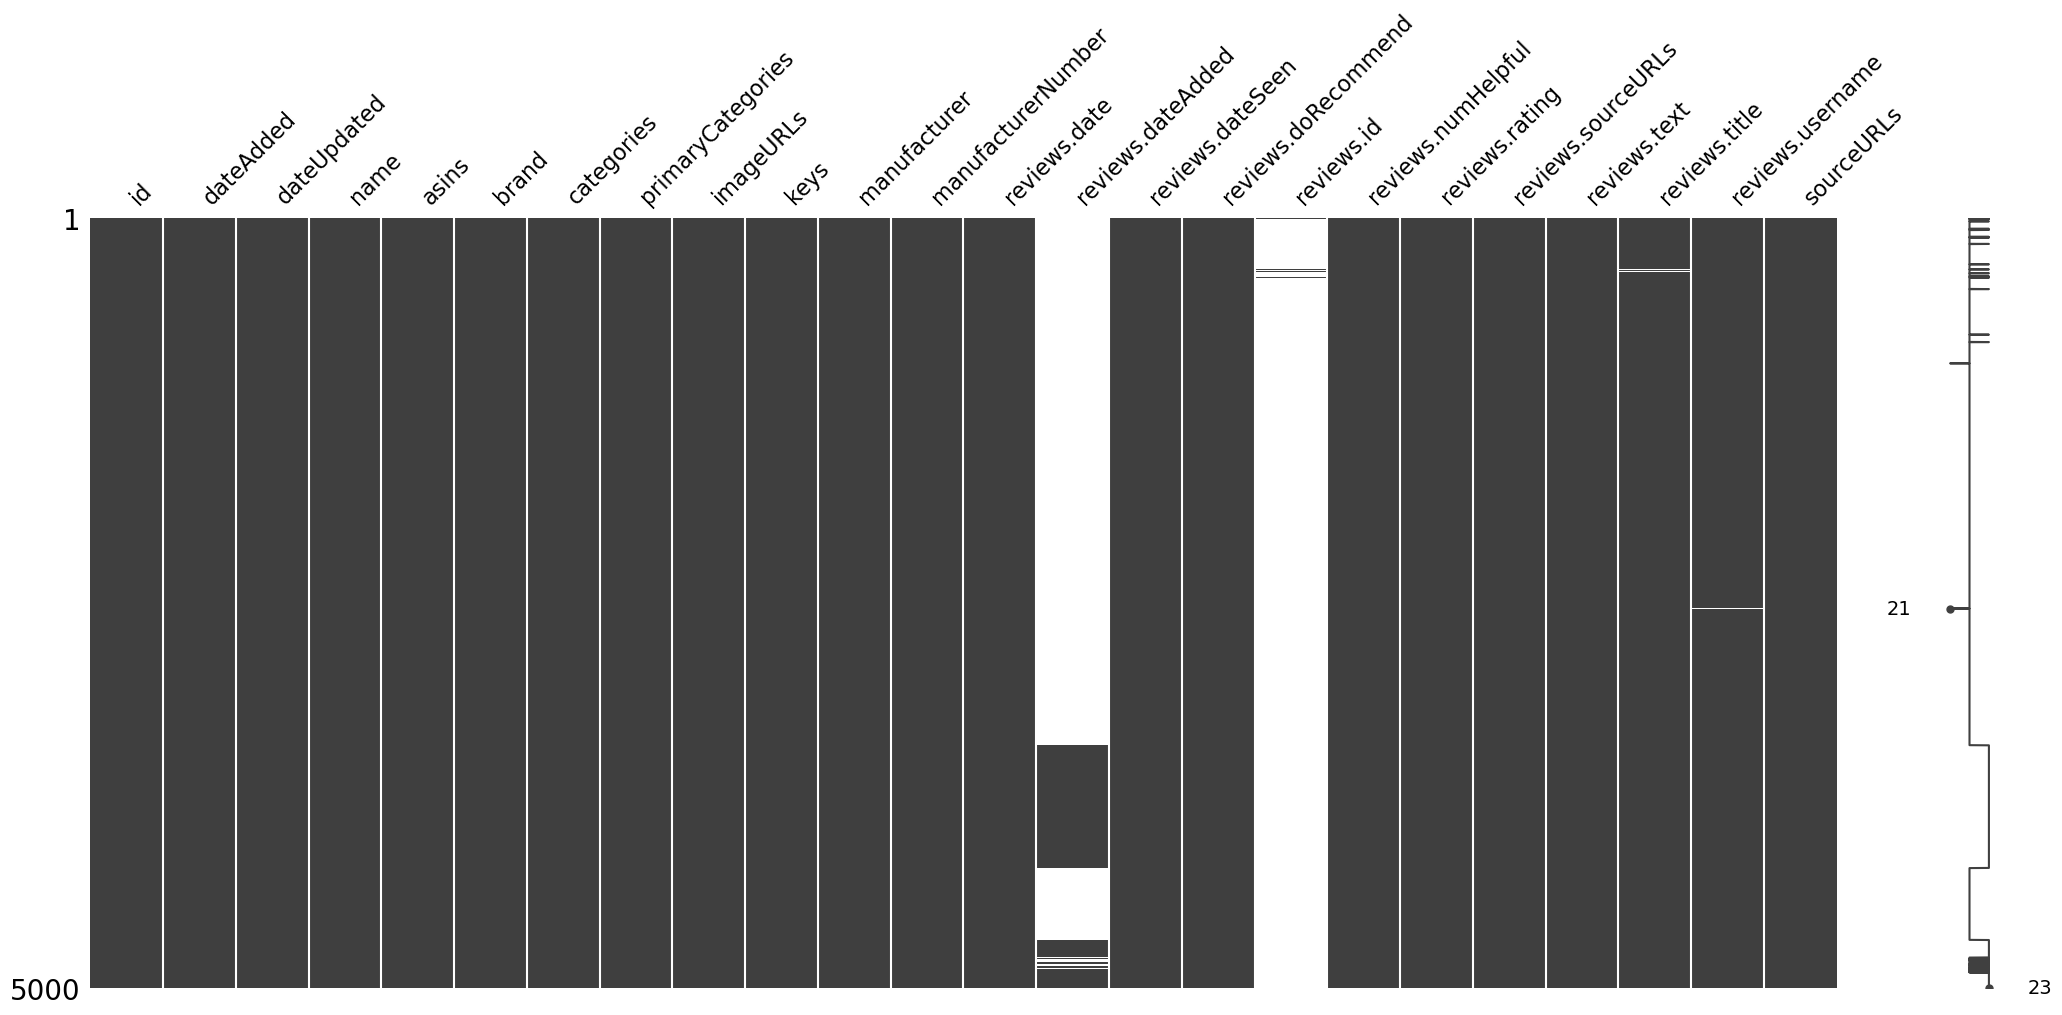

In [28]:
msno.matrix(df1)
plt.show()

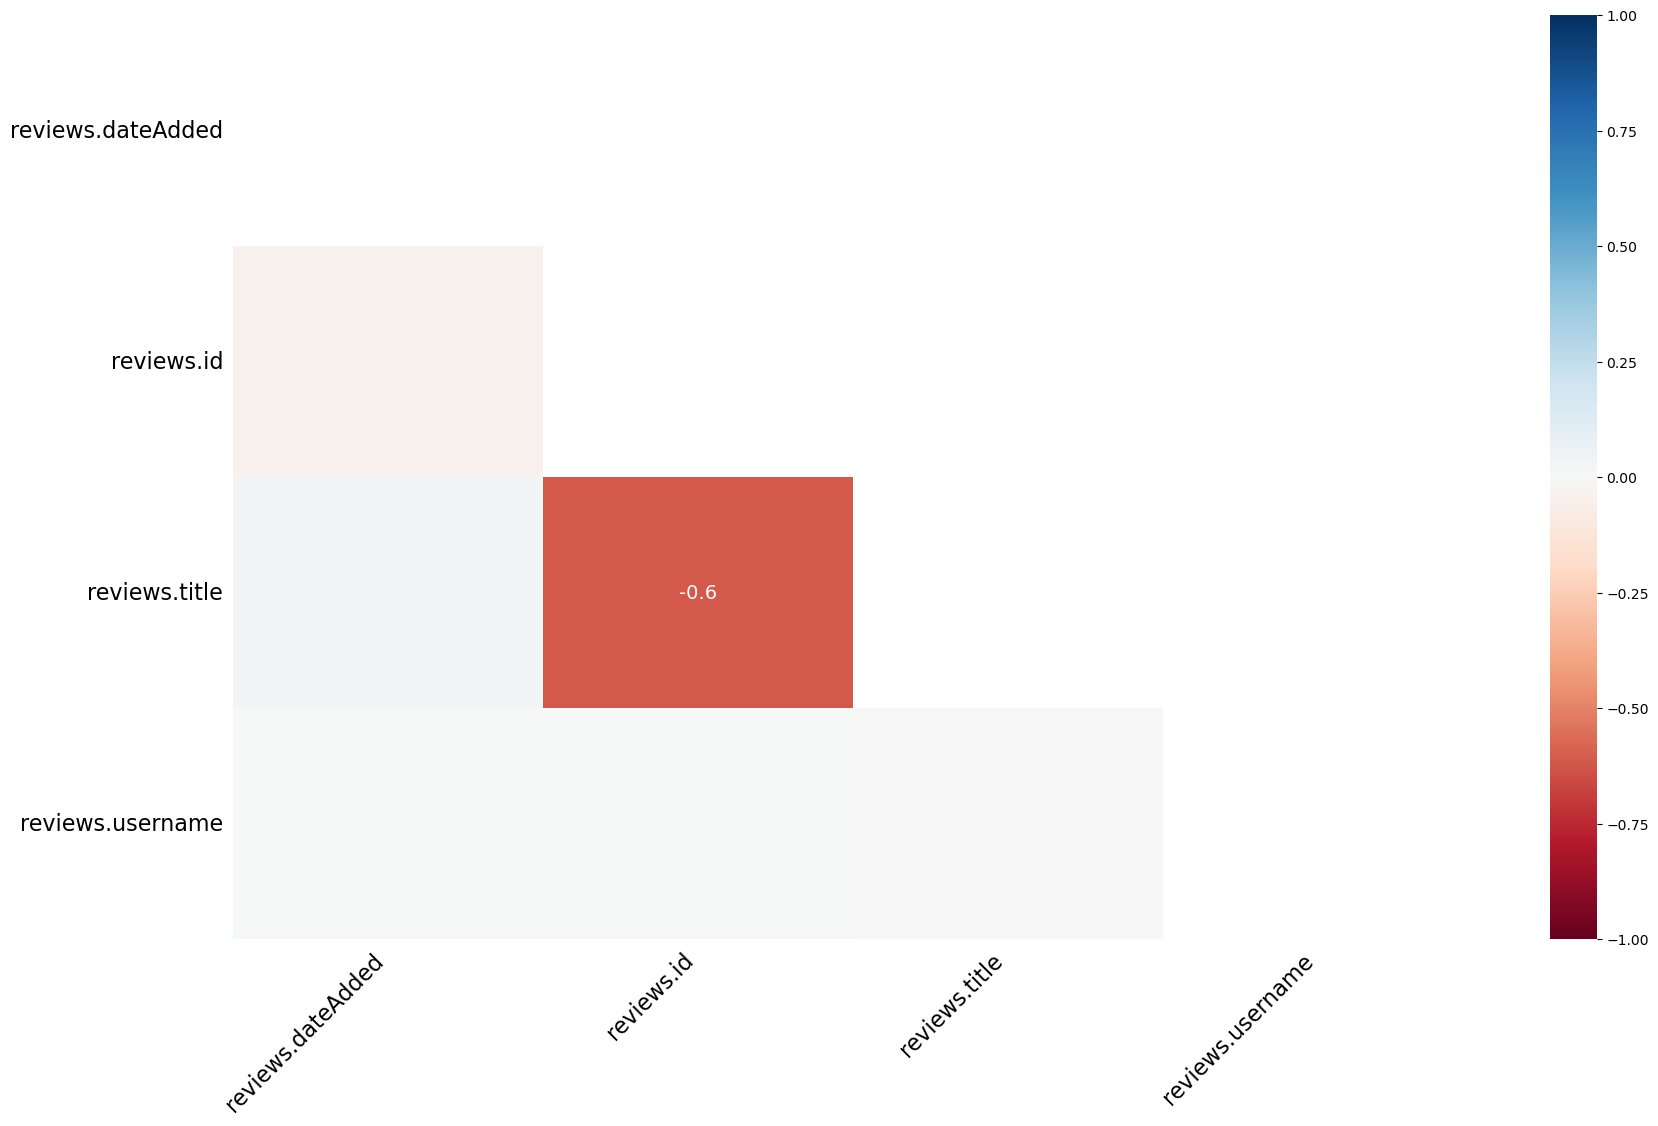

In [29]:
msno.heatmap(df1)
plt.show()

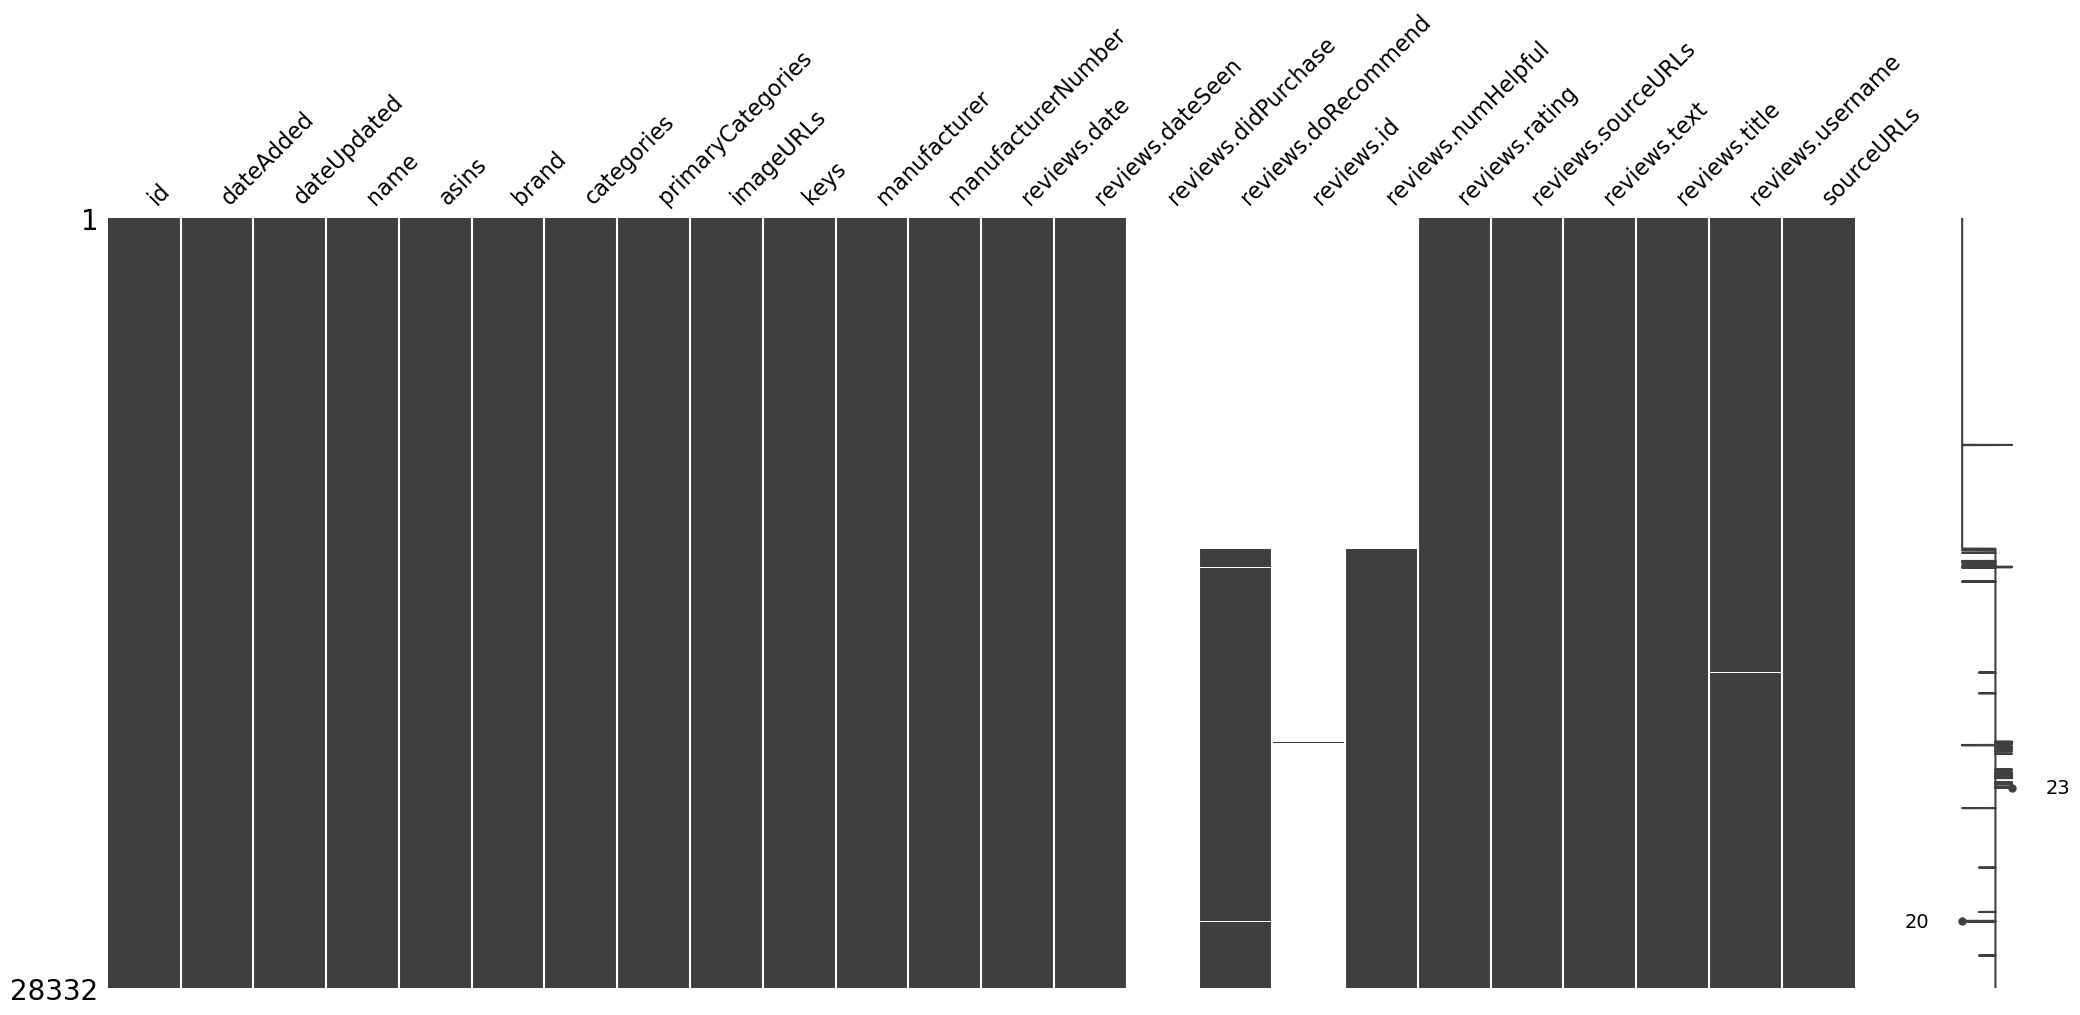

In [30]:
msno.matrix(df2)
plt.show()

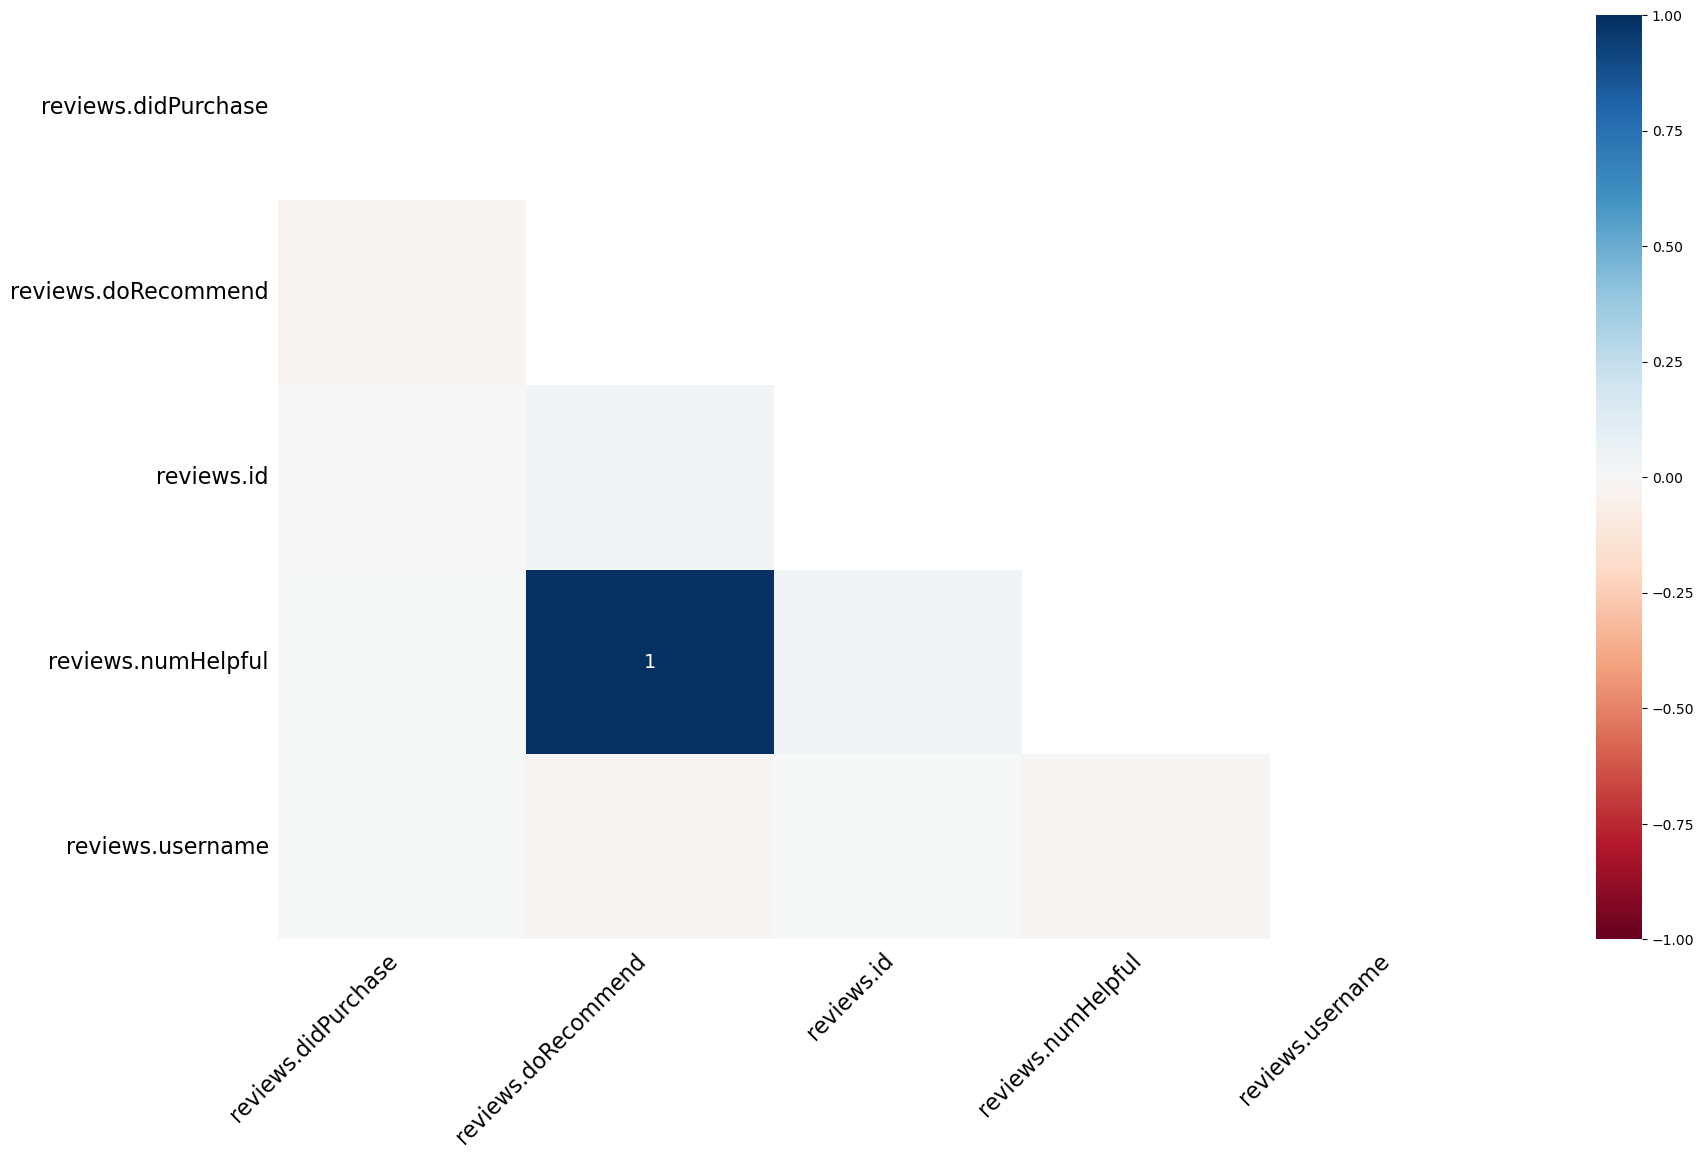

In [32]:
msno.heatmap(df2)
plt.show()

In [35]:
limit = len(df1) * 0.8
df1 = df1.dropna(thresh=limit, axis=1)

df1 = df1.dropna(subset=['reviews.text', 'reviews.rating'], how='all')

# Check if the column exists before trying to use it
if 'reviews.dateAdded' in df1.columns:
    df1['reviews.date'] = df1['reviews.dateAdded'].fillna('Unknown')
else:
    # Alternative: Create a new column with a default value
    df1['reviews.date'] = 'Unknown'
    # Or use another date column if available
    # df1['reviews.date'] = df1['some_other_date_column'].fillna('Unknown')

In [36]:
df2.drop(columns=['reviews.didPurchase', 'reviews.id'], inplace=True, errors='ignore')

df2['reviews.doRecommend'] = df2['reviews.doRecommend'].fillna(df2['reviews.doRecommend'].mode()[0])

df2['reviews.numHelpful'] = df2['reviews.numHelpful'].fillna(0)

df2.dropna(subset=['reviews.text', 'reviews.rating'], inplace=True)

print(f"Cleaned df2 shape: {df2.shape}")

Cleaned df2 shape: (28332, 22)


C:\Users\Shourya\AppData\Local\Temp\ipykernel_27180\2295779049.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['reviews.doRecommend'] = df2['reviews.doRecommend'].fillna(df2['reviews.doRecommend'].mode()[0])


In [47]:
def clean_cols(df):
    df.columns = [col.replace('.', '_').lower().strip() for col in df.columns]
    return df 

In [48]:
df1 = clean_cols(df1)
df2 = clean_cols(df2)

In [49]:
df1['reviews_date'] = pd.to_datetime(df1['reviews_date'], errors='coerce')
df2['reviews_date'] = pd.to_datetime(df2['reviews_date'], errors='coerce')

In [50]:
df2['reviews_rating'] = pd.to_numeric(df2['reviews_rating'], errors='coerce')

In [51]:
string_cols = ['brand', 'manufacturer', 'categories']

In [52]:
for col in string_cols:
    if col in df1.columns:
        df1[col] = df1[col].astype(str).str.strip().str.title()
    if col in df2.columns:
        df2[col] = df2[col].astype(str).str.strip().str.title()

In [53]:
df1['brand'] = df1['brand'].astype('category')
df2['brand'] = df2['brand'].astype('category')

In [54]:
print(f"Exact duplicates in df1: {df1.duplicated().sum()}")
print(f"Exact duplicates in df2: {df2.duplicated().sum()}")

Exact duplicates in df1: 95
Exact duplicates in df2: 0


In [55]:
df1 = df1.drop_duplicates()

In [56]:
logical_dupes = df2.duplicated(subset=['reviews_username', 'reviews_text', 'name'], keep='first').sum()
print(f"Logical duplicates found: {logical_dupes}")

Logical duplicates found: 57


In [57]:
df2 = df2.drop_duplicates(subset=['reviews_username', 'reviews_text', 'name'], keep='first')

In [59]:
df2['reviews_username'] = df2['reviews_username'].str.lower().str.strip()
df2 = df2.drop_duplicates(subset=['reviews_username', 'reviews_text', 'name'], keep='first')

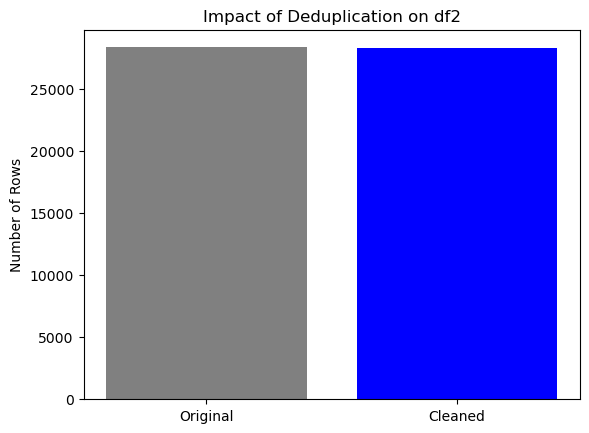

In [60]:
counts = [28332, len(df2)] # Original size vs Current size
labels = ['Original', 'Cleaned']

plt.bar(labels, counts, color=['gray', 'blue'])
plt.title('Impact of Deduplication on df2')
plt.ylabel('Number of Rows')
plt.show()

In [65]:
def treat_outliers(df, dataset_name):
    print(f"--- Processing Outliers for {dataset_name} ---")
 
    if 'reviews_numhelpful' in df.columns:
        Q1 = df['reviews_numhelpful'].quantile(0.25)
        Q3 = df['reviews_numhelpful'].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR

In [67]:
if 'reviews_text' in df.columns:
        initial_len = len(df)
        df = df[df['reviews_text'].str.len() >= 5].copy()
        print(f"Removed {initial_len - len(df)} reviews that were too short.")

In [69]:
df1 = treat_outliers(df1, "df1")
df2 = treat_outliers(df2, "df2")

--- Processing Outliers for df1 ---
--- Processing Outliers for df2 ---


In [71]:
def harmonize_categorical(df):
    # Check if df is None or not a dataframe before proceeding
    if df is None:
        print("Warning: DataFrame is None. Returning None.")
        return None
    
    if 'brand' in df.columns:
        df['brand'] = df['brand'].str.replace('Amazon.com', 'Amazon', case=False)
        df['brand'] = df['brand'].str.replace('Amazon.com, Inc.', 'Amazon', case=False)
    
    if 'categories' in df.columns:
        df['categories'] = df['categories'].str.lower().str.replace(' & ', ',')
    
    return df

# Make sure df1 and df2 exist and are dataframes before calling the function
if 'df1' in locals() and df1 is not None:
    df1 = harmonize_categorical(df1)
else:
    print("df1 is not defined or is None")

if 'df2' in locals() and df2 is not None:
    df2 = harmonize_categorical(df2)
else:
    print("df2 is not defined or is None")

df1 is not defined or is None
df2 is not defined or is None
